## Generate Data

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

In [ ]:
# Define holiday date ranges for 2025
HOLIDAYS = [
    (datetime(2025, 1, 1), datetime(2025, 1, 4)),      # Jan 1-4
    (datetime(2025, 2, 9), datetime(2025, 2, 24)),    # Feb 9-24
    (datetime(2025, 4, 20), datetime(2025, 5, 3)),    # Apr 20 - May 3
    (datetime(2025, 9, 1), datetime(2025, 9, 2)),      # Sep 1-2
    (datetime(2025, 10, 13), datetime(2025, 10, 17)),  # Oct 13-17
]

print("Holiday ranges defined:")
for start, end in HOLIDAYS:
    print(f"  {start.strftime('%b %d')} - {end.strftime('%b %d, %Y')}")

Holiday ranges defined:
  Jan 01 - Jan 04, 2025
  Feb 09 - Feb 24, 2025
  Apr 20 - May 03, 2025
  Sep 01 - Sep 02, 2025
  Oct 13 - Oct 17, 2025


In [ ]:
# Define consumption patterns by hour and day type
CONSUMPTION_PATTERNS = {
    'morning_early': {  # 0:00-5:00 (hours 0-5)
        'holiday': [40] * 6,
        'weekend': [40] * 6,
        'weekday': [40] * 6,
    },
    'morning_late': {  # 6:00-12:00 (hours 6-12)
        'holiday': [40] * 7,
        'weekend': [41, 50, 60, 55, 50, 55, 45],
        'weekday': [60, 205, 305, 300, 310, 300, 310],
    },
    'afternoon': {  # 13:00-19:00 (hours 13-19)
        'holiday': [45, 46, 47, 46, 44, 40, 40],
        'weekend': [46, 47, 47, 46, 44, 40, 40],
        'weekday': [375, 415, 390, 250, 90, 49, 42],
    },
    'evening': {  # 20:00-23:00 (hours 20-23)
        'holiday': [40] * 4,
        'weekend': [40] * 4,
        'weekday': [40] * 4,
    },
}

print("Consumption patterns defined for all time periods")

Consumption patterns defined for all time periods


In [ ]:
# Create helper functions
def is_holiday(date):
    """Check if a date is a holiday."""
    for start, end in HOLIDAYS:
        if start <= date <= end:
            return True
    return False

def get_day_type(date):
    """Determine if date is holiday, weekend, or weekday."""
    if is_holiday(date):
        return 'holiday'
    elif date.weekday() >= 5:  # Saturday=5, Sunday=6
        return 'weekend'
    else:
        return 'weekday'

def get_consumption_for_hour(hour, day_type):
    """Get consumption value for a specific hour and day type."""
    if 0 <= hour < 6:
        return CONSUMPTION_PATTERNS['morning_early'][day_type][hour]
    elif 6 <= hour < 13:
        return CONSUMPTION_PATTERNS['morning_late'][day_type][hour - 6]
    elif 13 <= hour < 20:
        return CONSUMPTION_PATTERNS['afternoon'][day_type][hour - 13]
    else:  # 20 <= hour < 24
        return CONSUMPTION_PATTERNS['evening'][day_type][hour - 20]

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [ ]:
# Generate hourly consumption data for 2025
def generate_load_data(year=2025):
    """Generate hourly consumption data for the entire year."""
    data = []
    
    start_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)
    
    current_date = start_date
    while current_date <= end_date:
        day_type = get_day_type(current_date)
        day_name = current_date.strftime('%A')
        
        for hour in range(24):
            consumption = get_consumption_for_hour(hour, day_type)
            
            data.append({
                'Date': current_date.strftime('%m/%d/%Y'),
                'Day': day_name,
                'Time': f'{hour:02d}:00',
                'Estimated Daily Load (kW)': consumption,
            })
        
        current_date += timedelta(days=1)
    
    return pd.DataFrame(data)

# Run the generation
df = generate_load_data(2025)
print(f"Generated hourly consumption data for 2025")
print(f"Total records: {len(df)} ({len(df) // 24} days × 24 hours)")

✓ Generated hourly consumption data for 2025
✓ Total records: 8760 (365 days × 24 hours)


In [ ]:
# Add Day_Type column to identify holidays, weekends, and weekdays

# Add Day_Type column using the existing helper function
df['Day_Type'] = df['Date'].apply(lambda x: get_day_type(datetime.strptime(x, '%m/%d/%Y')))

print("Added 'Day_Type' column")
print(f"Day Type distribution:")
print(df['Day_Type'].value_counts())
print(f"\nFirst 5 rows with Day_Type:")
print(df[['Date', 'Day', 'Time', 'Day_Type', 'Estimated Daily Load (kW)']].head())

✓ Added 'Day_Type' column
Day Type distribution:
Day_Type
weekday    5520
weekend    2256
holiday     984
Name: count, dtype: int64

First 5 rows with Day_Type:
         Date        Day   Time Day_Type  Estimated Daily Load (kW)
0  01/01/2025  Wednesday  00:00  holiday                         40
1  01/01/2025  Wednesday  01:00  holiday                         40
2  01/01/2025  Wednesday  02:00  holiday                         40
3  01/01/2025  Wednesday  03:00  holiday                         40
4  01/01/2025  Wednesday  04:00  holiday                         40


In [ ]:
# Save updated CSV with Day_Type column
# Navigate up one level from notebooks folder to reach project root
project_root = Path.cwd().parent
data_clean_dir = project_root / 'data' / 'clean'

# Create directory if it doesn't exist
data_clean_dir.mkdir(parents=True, exist_ok=True)

# Save the updated dataframe to CSV
output_file = data_clean_dir / 'hourly_consumption_2025.csv'
df.to_csv(output_file, index=False)

print(f"Project root: {project_root}")
print(f"Updated CSV saved to: {output_file}")
print(f"\nFirst 10 rows:")
print(df.head(10))

✓ Project root: c:\Data Processing
✓ Updated CSV saved to: c:\Data Processing\data\clean\hourly_consumption_2025.csv

First 10 rows:
         Date        Day   Time  Estimated Daily Load (kW) Day_Type
0  01/01/2025  Wednesday  00:00                         40  holiday
1  01/01/2025  Wednesday  01:00                         40  holiday
2  01/01/2025  Wednesday  02:00                         40  holiday
3  01/01/2025  Wednesday  03:00                         40  holiday
4  01/01/2025  Wednesday  04:00                         40  holiday
5  01/01/2025  Wednesday  05:00                         40  holiday
6  01/01/2025  Wednesday  06:00                         40  holiday
7  01/01/2025  Wednesday  07:00                         40  holiday
8  01/01/2025  Wednesday  08:00                         40  holiday
9  01/01/2025  Wednesday  09:00                         40  holiday


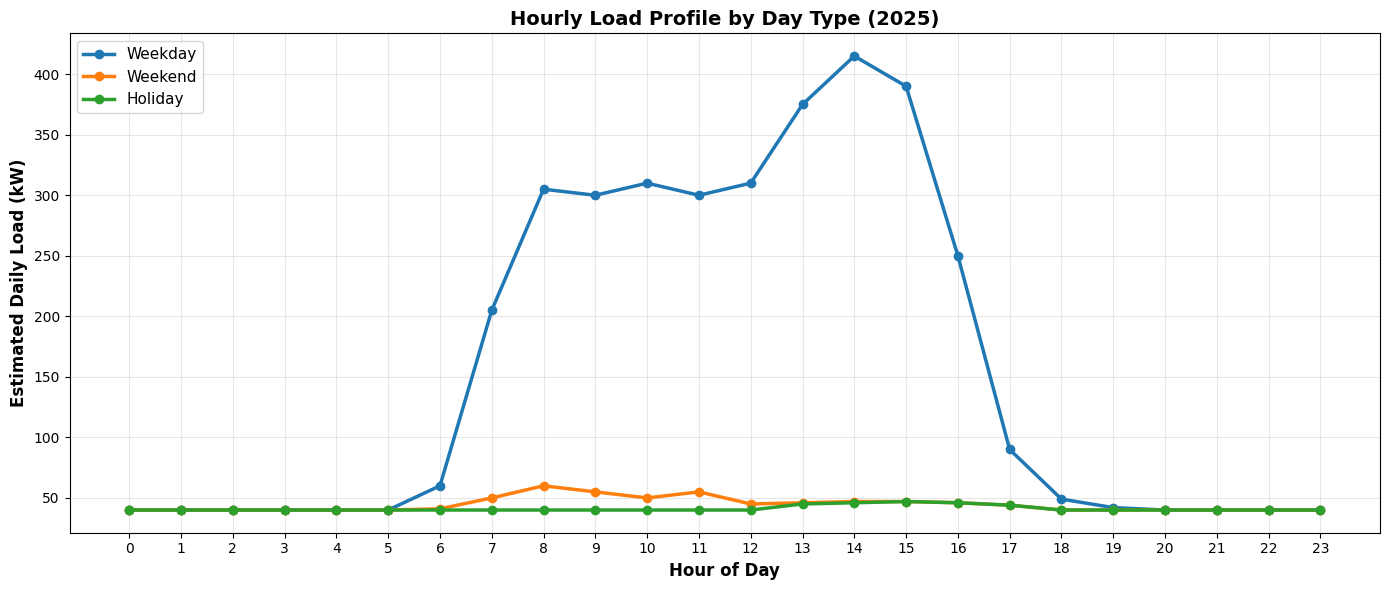


✓ Line chart generated successfully!

Hourly profile summary:
    Hour Day_Type  Estimated Daily Load (kW)
0      0  holiday                       40.0
1      0  weekday                       40.0
2      0  weekend                       40.0
3      1  holiday                       40.0
4      1  weekday                       40.0
..   ...      ...                        ...
67    22  weekday                       40.0
68    22  weekend                       40.0
69    23  holiday                       40.0
70    23  weekday                       40.0
71    23  weekend                       40.0

[72 rows x 3 columns]


In [ ]:
# Visualize hourly load profiles by day type using line chart
import matplotlib.pyplot as plt

# Extract hour from Time column
df['Hour'] = df['Time'].str.split(':').str[0].astype(int)

# Calculate average load by hour and day type
hourly_profile = df.groupby(['Hour', 'Day_Type'])['Estimated Daily Load (kW)'].mean().reset_index()

# Create line chart
plt.figure(figsize=(14, 6))

for day_type in ['weekday', 'weekend', 'holiday']:
    data = hourly_profile[hourly_profile['Day_Type'] == day_type]
    plt.plot(data['Hour'], data['Estimated Daily Load (kW)'], 
             marker='o', linewidth=2.5, label=day_type.capitalize(), markersize=6)

plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Estimated Daily Load (kW)', fontsize=12, fontweight='bold')
plt.title('Hourly Load Profile by Day Type (2025)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

print("\n✓ Line chart generated successfully!")
print("\nHourly profile summary:")
print(hourly_profile)

In [ ]:
# Verify different day types
print("=" * 60)
print("VERIFICATION: Sample data from different day types")
print("=" * 60)

# Holiday example (Jan 1, 2025 - Wednesday during holiday)
print("\n HOLIDAY SAMPLE (Jan 1, 2025 - Wednesday):")
print(df[(df['Date'] == '01/01/2025')].head(13))

# Weekday example (Jan 6, 2025 - Monday)
print("\n WEEKDAY SAMPLE (Jan 6, 2025 - Monday):")
print(df[(df['Date'] == '01/06/2025')].head(13))

# Weekend example (Jan 4, 2025 - Saturday)
print("\n WEEKEND SAMPLE (Jan 4, 2025 - Saturday):")
print(df[(df['Date'] == '01/04/2025')].head(13))

# Regular weekday (Jan 8, 2025 - Wednesday, not holiday)
print("\n REGULAR WEEKDAY (Jan 8, 2025 - Wednesday):")
print(df[(df['Date'] == '01/08/2025')].head(13))

VERIFICATION: Sample data from different day types

📅 HOLIDAY SAMPLE (Jan 1, 2025 - Wednesday):
          Date        Day   Time  Estimated Daily Load (kW)
0   01/01/2025  Wednesday  00:00                         40
1   01/01/2025  Wednesday  01:00                         40
2   01/01/2025  Wednesday  02:00                         40
3   01/01/2025  Wednesday  03:00                         40
4   01/01/2025  Wednesday  04:00                         40
5   01/01/2025  Wednesday  05:00                         40
6   01/01/2025  Wednesday  06:00                         40
7   01/01/2025  Wednesday  07:00                         40
8   01/01/2025  Wednesday  08:00                         40
9   01/01/2025  Wednesday  09:00                         40
10  01/01/2025  Wednesday  10:00                         40
11  01/01/2025  Wednesday  11:00                         40
12  01/01/2025  Wednesday  12:00                         40

📅 WEEKDAY SAMPLE (Jan 6, 2025 - Monday):
           Date     Da

In [ ]:
# Step 7: Verify data integrity - Ensure exactly 8760 rows (365 days × 24 hours)
print("\n" + "=" * 60)
print("DATA INTEGRITY VERIFICATION")
print("=" * 60)

# Total records check
total_rows = len(df)
expected_rows = 365 * 24

print(f"\n Total records: {total_rows}")
print(f" Expected records: {expected_rows}")

if total_rows == expected_rows:
    print(f" PASS: Data has exactly {expected_rows} rows!")
else:
    print(f" FAIL: Data has {total_rows} rows, expected {expected_rows}")

# Records per day check
records_per_day = df.groupby('Date').size()
print(f"\n Records per day (should be 24 for all dates):")
print(f"  Min: {records_per_day.min()}")
print(f"  Max: {records_per_day.max()}")
print(f"  Expected: 24")

if records_per_day.min() == 24 and records_per_day.max() == 24:
    print(f" PASS: All dates have exactly 24 hourly records")
else:
    print(f" FAIL: Some dates have incorrect number of records")

# Unique dates check
unique_dates = df['Date'].nunique()
print(f"\n Unique dates: {unique_dates}")
print(f" Expected: 365")

if unique_dates == 365:
    print(f" PASS: Data covers exactly 365 days")
else:
    print(f" FAIL: Data covers {unique_dates} days, expected 365")

# Final summary
print(f"\n" + "=" * 60)
if total_rows == 8760 and unique_dates == 365 and records_per_day.min() == 24:
    print(f" ALL CHECKS PASSED - Data is complete and valid!")
else:
    print(f" SOME CHECKS FAILED - Review data generation")
print("=" * 60)


DATA INTEGRITY VERIFICATION

✓ Total records: 8760
✓ Expected records: 8760
✅ PASS: Data has exactly 8760 rows!

✓ Records per day (should be 24 for all dates):
  Min: 24
  Max: 24
  Expected: 24
✅ PASS: All dates have exactly 24 hourly records

✓ Unique dates: 365
✓ Expected: 365
✅ PASS: Data covers exactly 365 days

✅ ALL CHECKS PASSED - Data is complete and valid!
